In [2]:
def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 14
bound = 5
output = elliptic_fourier_expansions(level, bound)
print(len(output))
print()
print(output)
print()
print(output[0])
print()
print(output[0][1])

1

[('14a1', [(1, 1), (2, -1), (3, -2), (4, 1), (5, 0)])]

('14a1', [(1, 1), (2, -1), (3, -2), (4, 1), (5, 0)])

[(1, 1), (2, -1), (3, -2), (4, 1), (5, 0)]


In [3]:
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast

def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 14
bound = 401
output = elliptic_fourier_expansions(level, bound)
data=output[0]
label = data[0]
expansion=data[1]
print("label:", label)
print("expansion[:5]:",expansion[:5])

label: 14a1
expansion[:5]: [(1, 1), (2, -1), (3, -2), (4, 1), (5, 0)]


In [32]:
nth_prime(400)

2741

In [ ]:
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast

def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 14
bound =2800
output = elliptic_fourier_expansions(level, bound)
data=output[0]
label = data[0]
expansion=data[1]
print("label:", label)
prime_list_no_offset=[pair for pair in expansion if is_prime(pair[0])]
coeffs_list=[pair[1] for pair in prime_list_no_offset]

    
h_list=[1]+coeffs_list # h_0 = 1 required by the lemmas
j_list=[(0,1)] # first entry is just an offset. 
for n in range(1,401):# so j(1) = 1 = h(0) as required.
    sm=0
    for r in [1..n-1]: 
        sm=sm+j_list[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    print((n,j_n))
    j_list.append((n,j_n))

with open('/Users/barrybrent/data2/run9mar26no100.txt', 'wb') as wfile:
    pickle.dump(prime_list_no_offset, wfile) 
    
with open('/Users/barrybrent/data2/run9mar26no101.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 

1 0.00035335620244344074
2 0.0003881176312764486
3 0.0004063685735066732
4 0.00042260090510050455
5 0.00044495264689127604
6 0.00047347148259480797
7 0.0005065004030863444
8 0.0005457321802775065
9 0.0005977710088094075
10 0.0006589531898498535
11 0.0007234533627827962
12 0.0007925192515055338
13 0.0008748849232991536
14 0.0010234038035074869
15 0.001197203000386556
16 0.0013422687848409017
17 0.0015620708465576172
18 0.0018384377161661783
19 0.0021531383196512857
20 0.0025513529777526855
21 0.002950135866800944
22 0.0032038052876790365
23 0.0034998019536336264
24 0.0038058678309122723
25 0.00418175458908081
26 0.0045663396517435706
27 0.00492168664932251
28 0.005392638842264811
29 0.005871586004892985
30 0.00649648904800415
31 0.007034806410471598
32 0.008027533690134684
33 0.009056568145751953
34 0.010055001576741536
35 0.011104683081309
36 0.012473189830780029
37 0.013933885097503661
38 0.015399587154388428
39 0.016454136371612547
40 0.017454902331034344
41 0.01852383613586426
42 0.

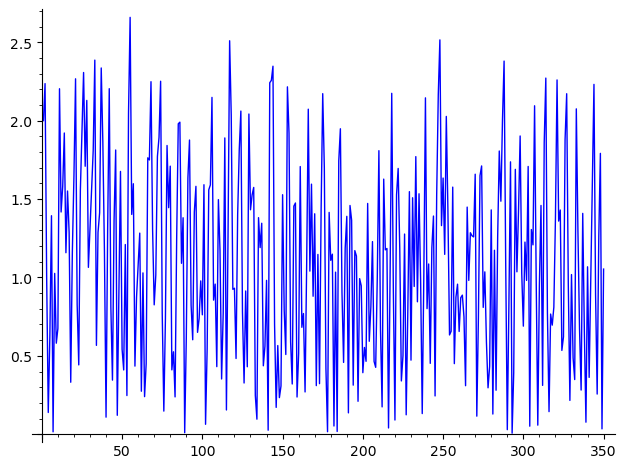

In [4]:
import pickle
from sage.all import sigma, nth_prime
import ast
import time

start=time.time()
#######################################################################
#with open('/Users/barrybrent/data2/run9mar26no1.txt', 'rb') as rfile:
#    j_list = pickle.load(rfile) ##
# wrong file 

def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()

from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable

charpol_list=[]
roots_list=[]

mins_list=[]
log_mins_list=[]

dets=[]

for n in range(1, 351):
    print(n,(time.time()-start)/60)
    deformed_j_list=j_list[:n]
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) 
    det=pl.det()
    dets.append((n,det))
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    if aar!=[]:
        minn = min(aar)  
        mins_list.append((n,minn))
        if minn>0:
            log_minn=log(minn)
            log_mins_list.append((n,log_minn))
        


p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()



with open('/Users/barrybrent/data2/run26mar26no102.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run26mar26no103.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run26mar26no105.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped
